In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/PK-SubCpmk 3/cases.csv"

df = pd.read_csv(file_path)

df.head()

,case_id,no_perkara,tanggal,ringkasan_fakta,pasal,pihak,amar_putusan,text_full
0,1,1074/Pid.B/2025/PN Bdg,2025-09-19,Kesatu Penuntut Umum; 2. Menjatuhkan pidana te...,Pasal 378 KUHP; Pasal\n378 KUHP; Pasal\n372 KU...,DERIN HARISTYA UKITA Bin SUHENDAR HARIS,1. Menyatakan Terdakwa DERIN HARISTYA UKITA Bi...,P U T U S A N\nNomor 1074/Pid.B/2025/PN Bdg\n\...
1,2,1091/Pid.B/2025/PN Bdg,2025-11-17,alternatif Kedua: Pasal 374 KUHP jo 64 ayat (1...,Pasal 374 KUHP; Pasal\n378 KUHP; Pasal 378 KUH...,MUHAMAD ISSYAK HUSEN AMD BIN DJANDJAN,1. Menyatakan Terdakwa MUHAMAD ISSYAK HUSEN AM...,P U T U S A N\nNomor 1091/Pid.B/2025/PN Bdg\nD...
2,3,1099/Pid.B/2025/PN Bdg,2025-09-20,Kesatu. 2. Menjatuhkan pidana terhadap Terdakw...,pasal 378\nKUHP; pasal 378 KUHP; pasal 372 KUH...,Ardy Putra Auwy anak dari Ferdianto Auwy,1. Menyatakan Terdakwa Ardy Putra Auwy anak da...,Hal. 1 dari 56 halaman Putusan Nomor 1099/Pid....
3,4,1100/Pid.B/2024/PN Bdg,2024-10-21,Alternatif Pertama; 2. Menjatuhkan pidana terh...,pasal 378 KUHP; Pasal 372\nKUHP; Pasal 378 KUHP,MUHAMMAD IKHSAN GUNAWAN Bin,1. Menyatakan terdakwa MUHAMMAD IKHSAN GUNAWAN...,P U T U S A N\nNomor 1100/Pid.B/2024/PN Bdg\nD...
4,5,1104/Pid.B/2025/PN Bdg,2025-02-25,alternatif Kesatu kami melanggar pasal 378 KUH...,pasal 378 KUHP; Pasal\n378 KUHP; pasal 372 KUH...,RUDY SYARIF,1.\nMenyatakan Terdakwa RUDY SYARIF telah terb...,P U T U S A N\nNomor 1104/Pid.B/2025/PN Bdg\n\...


In [ ]:
df.columns

Index(['case_id', 'no_perkara', 'tanggal', 'ringkasan_fakta', 'pasal', 'pihak',
       'amar_putusan', 'text_full'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_df))
print("Test :", len(test_df))

Train: 40
Test : 10


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words=None,
    max_features=5000
)

X_train = vectorizer.fit_transform(train_df['text_full'])

print(X_train.shape)

(40, 5000)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieve(query, k=5):

    query_vec = vectorizer.transform([query])

    similarities = cosine_similarity(
        query_vec,
        X_train
    ).flatten()

    top_idx = similarities.argsort()[::-1][:k]

    results = train_df.iloc[top_idx][
        ['case_id','no_perkara']
    ].copy()

    results['similarity'] = similarities[top_idx]

    return results

In [ ]:
import pandas as pd

queries = [
    {
        "query_id": 1,
        "query": "penipuan jual beli sepeda motor",
        "ground_truth_case_id": 1
    },
    {
        "query_id": 2,
        "query": "penggelapan uang perusahaan oleh karyawan",
        "ground_truth_case_id": 2
    },
    {
        "query_id": 3,
        "query": "penipuan kendaraan bermotor",
        "ground_truth_case_id": 4
    },
    {
        "query_id": 4,
        "query": "penipuan pengurusan warisan dan tanah",
        "ground_truth_case_id": 5
    },
    {
        "query_id": 5,
        "query": "penipuan investasi atau kerja sama usaha",
        "ground_truth_case_id": 8
    },
    {
        "query_id": 6,
        "query": "penipuan dengan tipu muslihat",
        "ground_truth_case_id": 9
    },
    {
        "query_id": 7,
        "query": "penggelapan yang dilakukan secara berlanjut",
        "ground_truth_case_id": 10
    },
    {
        "query_id": 8,
        "query": "penipuan pembelian kendaraan dan barang rumah tangga",
        "ground_truth_case_id": 11
    },
    {
        "query_id": 9,
        "query": "penggelapan sepeda motor oleh pelaku",
        "ground_truth_case_id": 44
    },
    {
        "query_id": 10,
        "query": "penipuan dengan janji keuntungan bisnis",
        "ground_truth_case_id": 45
    }
]

queries_df = pd.DataFrame(queries)

queries_df

,query_id,query,ground_truth_case_id
0,1,penipuan jual beli sepeda motor,1
1,2,penggelapan uang perusahaan oleh karyawan,2
2,3,penipuan kendaraan bermotor,4
3,4,penipuan pengurusan warisan dan tanah,5
4,5,penipuan investasi atau kerja sama usaha,8
5,6,penipuan dengan tipu muslihat,9
6,7,penggelapan yang dilakukan secara berlanjut,10
7,8,penipuan pembelian kendaraan dan barang rumah ...,11
8,9,penggelapan sepeda motor oleh pelaku,44
9,10,penipuan dengan janji keuntungan bisnis,45


In [ ]:
import json
output_path = "/content/drive/MyDrive/PK-SubCpmk 3/queries.json"

In [ ]:
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(
        queries,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Berhasil disimpan:", output_path)

Berhasil disimpan: /content/drive/MyDrive/PK-SubCpmk 3/queries.json


In [ ]:
import json

with open("queries.json", "w", encoding="utf-8") as f:
    json.dump(queries, f, indent=4, ensure_ascii=False)

print("queries.json berhasil dibuat")

queries.json berhasil dibuat


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_df))
print("Test :", len(test_df))

Train: 40
Test : 10


In [ ]:
vectorizer.fit(train_df['text_full'])

TfidfVectorizer(max_features=5000)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df['text_full'])

print(X_train.shape)

(40, 5000)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieve(query, k=5):

    query_vec = vectorizer.transform([query])

    similarities = cosine_similarity(
        query_vec,
        X_train
    ).flatten()

    top_idx = similarities.argsort()[::-1][:k]

    results = train_df.iloc[top_idx][
        ['case_id', 'no_perkara']
    ].copy()

    results['similarity'] = similarities[top_idx]

    return results

In [ ]:
query = "penipuan jual beli sepeda motor"

retrieve(query, k=5)

,case_id,no_perkara,similarity
3,4,1100/Pid.B/2024/PN Bdg,0.392060
0,1,1074/Pid.B/2025/PN Bdg,0.301268
43,44,831/Pid.B/2025/PN Bdg,0.180222
14,15,183/Pid.B/2025/PN Bdg,0.089218
10,11,166 / Pid.B / 2021 / PN.Bdg.,0.085761


In [ ]:
import json

with open("queries.json", "r", encoding="utf-8") as f:
    queries = json.load(f)

In [ ]:
results = []

for item in queries:

    query = item["query"]
    gt = item["ground_truth_case_id"]

    retrieved = retrieve(query, k=5)

    retrieved_ids = retrieved["case_id"].tolist()

    hit = 1 if gt in retrieved_ids else 0

    results.append({
        "query_id": item["query_id"],
        "query": query,
        "ground_truth": gt,
        "retrieved_ids": retrieved_ids,
        "hit": hit
    })

In [ ]:
import pandas as pd

eval_df = pd.DataFrame(results)

eval_df

,query_id,query,ground_truth,retrieved_ids,hit
0,1,penipuan jual beli sepeda motor,1,"[4, 1, 44, 15, 11]",1
1,2,penggelapan uang perusahaan oleh karyawan,2,"[2, 37, 8, 6, 11]",1
2,3,penipuan kendaraan bermotor,4,"[19, 39, 12, 11, 15]",0
3,4,penipuan pengurusan warisan dan tanah,5,"[5, 23, 24, 43, 42]",1
4,5,penipuan investasi atau kerja sama usaha,8,"[3, 36, 15, 8, 2]",1
5,6,penipuan dengan tipu muslihat,9,"[4, 22, 44, 34, 36]",0
6,7,penggelapan yang dilakukan secara berlanjut,10,"[22, 19, 2, 9, 8]",0
7,8,penipuan pembelian kendaraan dan barang rumah ...,11,"[19, 11, 12, 39, 34]",1
8,9,penggelapan sepeda motor oleh pelaku,44,"[4, 1, 44, 11, 12]",1
9,10,penipuan dengan janji keuntungan bisnis,45,"[29, 28, 8, 36, 22]",0


In [ ]:
results = []

for item in queries:

    query = item["query"]

    retrieved = retrieve(query, k=5)

    retrieved_ids = retrieved["case_id"].tolist()

    results.append({
        "query_id": item["query_id"],
        "query": query,
        "top_5_case_ids": retrieved_ids
    })

retrieval_df = pd.DataFrame(results)

retrieval_df

,query_id,query,top_5_case_ids
0,1,penipuan jual beli sepeda motor,"[4, 1, 44, 15, 11]"
1,2,penggelapan uang perusahaan oleh karyawan,"[2, 37, 8, 6, 11]"
2,3,penipuan kendaraan bermotor,"[19, 39, 12, 11, 15]"
3,4,penipuan pengurusan warisan dan tanah,"[5, 23, 24, 43, 42]"
4,5,penipuan investasi atau kerja sama usaha,"[3, 36, 15, 8, 2]"
5,6,penipuan dengan tipu muslihat,"[4, 22, 44, 34, 36]"
6,7,penggelapan yang dilakukan secara berlanjut,"[22, 19, 2, 9, 8]"
7,8,penipuan pembelian kendaraan dan barang rumah ...,"[19, 11, 12, 39, 34]"
8,9,penggelapan sepeda motor oleh pelaku,"[4, 1, 44, 11, 12]"
9,10,penipuan dengan janji keuntungan bisnis,"[29, 28, 8, 36, 22]"


In [ ]:
output_path = "/content/drive/MyDrive/PK-SubCpmk 3/retrieval_results.csv"

retrieval_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Berhasil disimpan:", output_path)

Berhasil disimpan: /content/drive/MyDrive/PK-SubCpmk 3/retrieval_results.csv


In [ ]:
accuracy = eval_df["hit"].mean()

print("Accuracy@5 =", accuracy)

Accuracy@5 = 0.6


# EVALUASI

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
y_true = []
y_pred = []

for item in queries:

    gt = item["ground_truth_case_id"]

    retrieved = retrieve(item["query"], k=5)

    retrieved_ids = retrieved["case_id"].tolist()

    y_true.append(1)

    if gt in retrieved_ids:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.6000
Precision: 1.0000
Recall   : 0.6000
F1-Score : 0.7500


In [ ]:
retrieval_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

retrieval_metrics

,Metric,Value
0,Accuracy,0.60
1,Precision,1.00
2,Recall,0.60
3,F1-Score,0.75


In [ ]:
retrieval_metrics.to_csv(
    "/content/drive/MyDrive/PK-SubCpmk 3/retrieval_metrics.csv",
    index=False
)

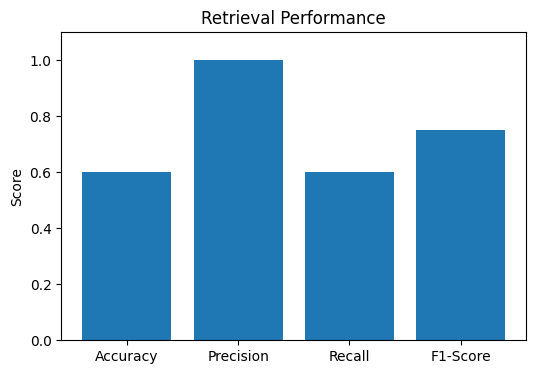

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [0.60, 1.00, 0.60, 0.75]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylim(0,1.1)
plt.ylabel("Score")
plt.title("Retrieval Performance")
plt.show()

In [ ]:
plt.savefig(
    "/content/drive/MyDrive/PK-SubCpmk 3/retrieval_performance.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>